# Classification

In [3]:
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data_dir = '/content/'

# Load saved splits
X_train = pd.read_csv(data_dir + 'X_clf_train.csv')
X_test  = pd.read_csv(data_dir + 'X_clf_test.csv')
y_train = pd.read_csv(data_dir + 'y_clf_train.csv').squeeze()
y_test  = pd.read_csv(data_dir + 'y_clf_test.csv').squeeze()

print("Shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print("Class balance (train):\n", y_train.value_counts(normalize=True))

Shapes: (7200, 27) (1800, 27) (7200,) (1800,)
Class balance (train):
 placed
1    0.855833
0    0.144167
Name: proportion, dtype: float64


In [ ]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv=5):
    # Cross-val on training data
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=skf,
                                scoring='f1', n_jobs=-1)

    # Fit on full training set & predict on test
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    return {
        'Model':      name,
        'CV F1 (mean)': round(cv_scores.mean(), 4),
        'CV F1 (std)':  round(cv_scores.std(), 4),
        'Accuracy':   round(accuracy_score(y_te, y_pred), 4),
        'Precision':  round(precision_score(y_te, y_pred), 4),
        'Recall':     round(recall_score(y_te, y_pred), 4),
        'F1':         round(f1_score(y_te, y_pred), 4),
        'ROC-AUC':    round(roc_auc_score(y_te, y_proba), 4),
        '_fitted':    model,
        '_y_pred':    y_pred,
    }

In [ ]:
# Logistic Regression

logreg = LogisticRegression(max_iter=1000, random_state=42)
param_grid_lr = {
    'C':       [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver':  ['lbfgs']
}
gs_lr = GridSearchCV(logreg, param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
gs_lr.fit(X_train, y_train)
print("Best LR params:", gs_lr.best_params_)

res_lr = evaluate_model("Logistic Regression", gs_lr.best_estimator_,
                        X_train, y_train, X_test, y_test)

Best LR params: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}


In [ ]:
# Random Forest
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid_rf = {
    'n_estimators':      [200, 400],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5]
}
gs_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
gs_rf.fit(X_train, y_train)
print("Best RF params:", gs_rf.best_params_)

res_rf = evaluate_model("Random Forest", gs_rf.best_estimator_,
                        X_train, y_train, X_test, y_test)

Best RF params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 400}


In [ ]:
#XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='logloss',
                    use_label_encoder=False, n_jobs=-1)
param_grid_xgb = {
    'n_estimators':  [200, 400],
    'max_depth':     [3, 6],
    'learning_rate': [0.05, 0.1]
}
gs_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='f1', n_jobs=-1)
gs_xgb.fit(X_train, y_train)
print("Best XGB params:", gs_xgb.best_params_)

res_xgb = evaluate_model("XGBoost", gs_xgb.best_estimator_,
                         X_train, y_train, X_test, y_test)

Best XGB params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


In [ ]:
results_df = pd.DataFrame([res_lr, res_rf, res_xgb]).drop(columns=['_fitted', '_y_pred'])
results_df = results_df.sort_values('F1', ascending=False).reset_index(drop=True)
print("\n=== BASELINE CLASSIFICATION RESULTS ===")
display(results_df)


=== BASELINE CLASSIFICATION RESULTS ===


,Model,CV F1 (mean),CV F1 (std),Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.9524,0.0067,0.9250,0.9404,0.9740,0.9569,0.9714
1,XGBoost,0.9507,0.0058,0.9206,0.9341,0.9760,0.9546,0.9639
2,Random Forest,0.9459,0.0041,0.9128,0.9255,0.9766,0.9504,0.9541


**Logistic Regression**
* Highest F1 score and very high Recall (catches most actual placed students)
* Very stable (low std = 0.0067)

**XGBoost**
* Highest Recall among all models
* Very close to Logistic Regression in performance
* Slightly more complex but still very stable

**Random Forest**
* Also has very high Recall
* Performs slightly worse than the other two in overall balance

**Conclusion:**

Use XGBoost as the primary model for SHAP analysis. The performance gap vs. Logistic Regression is tiny (F1 0.9546 vs 0.9569), but the interpretability payoff is much richer since SHAP can expose non-linear patterns and feature interactions in the placement data.

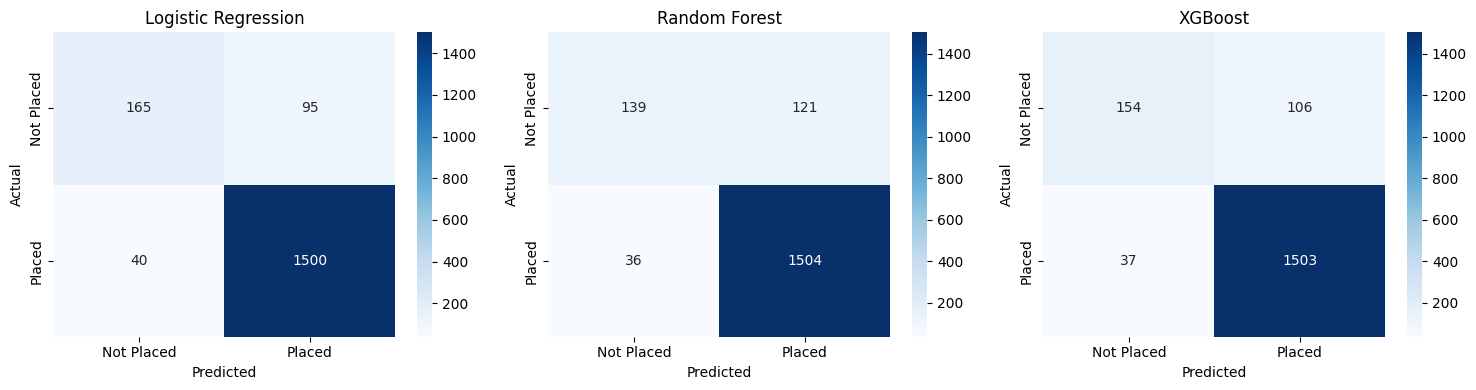

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, res in zip(axes, [res_lr, res_rf, res_xgb]):
    cm = confusion_matrix(y_test, res['_y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Placed','Placed'],
                yticklabels=['Not Placed','Placed'])
    ax.set_title(res['Model'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

# Regression

In [1]:
from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import shap

In [4]:
data_dir = '/content/'

# Load saved splits
X_train = pd.read_csv(data_dir + 'X_reg_train.csv')
X_test  = pd.read_csv(data_dir + 'X_reg_test.csv')
y_train = pd.read_csv(data_dir + 'y_reg_train.csv').squeeze()
y_test  = pd.read_csv(data_dir + 'y_reg_test.csv').squeeze()

print("Shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print("Target stats (train):\n", y_train.describe())

Shapes: (6161, 31) (1541, 31) (6161,) (1541,)
Target stats (train):
 count    6161.000000
mean       64.702636
std        17.128824
min        32.830000
25%        48.840000
50%        65.870000
75%        77.580000
max       129.430000
Name: salary_lpa, dtype: float64


In [5]:
def evaluate_reg(model, X_tr, y_tr, X_te, y_te, name, cv=5):
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    cv_r2 = cross_val_score(model, X_tr, y_tr, scoring='r2', cv=kf, n_jobs=-1)

    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    mae  = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2   = r2_score(y_te, preds)

    print(f"\n=== {name} ===")
    print(f"CV R² (mean ± std): {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    print(f"Test MAE : {mae:.4f}")
    print(f"Test RMSE: {rmse:.4f}")
    print(f"Test R²  : {r2:.4f}")

    return {
        'Model': name,
        'CV R2 (mean)': round(cv_r2.mean(), 4),
        'CV R2 (std)':  round(cv_r2.std(), 4),
        'MAE':  round(mae, 4),
        'RMSE': round(rmse, 4),
        'R2':   round(r2, 4),
        '_fitted': model,
    }

In [6]:
#XGBoost Regressor
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=42, n_jobs=-1, tree_method='hist'
)

xgb_grid = {
    'n_estimators':   [200, 400, 600],
    'max_depth':      [3, 5, 7],
    'learning_rate':  [0.03, 0.05, 0.1],
    'subsample':      [0.8, 1.0],
    'colsample_bytree':[0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    xgb_base, xgb_grid, n_iter=12, scoring='r2',
    cv=3, random_state=42, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train, y_train)
print("Best XGB params:", xgb_search.best_params_)

res_xgb = evaluate_reg(xgb_search.best_estimator_, X_train, y_train,
                       X_test, y_test, "XGBoost Regressor")

Best XGB params: {'subsample': 0.8, 'n_estimators': 600, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.8}

=== XGBoost Regressor ===
CV R² (mean ± std): 0.8512 ± 0.0045
Test MAE : 5.5212
Test RMSE: 6.6780
Test R²  : 0.8393


In [7]:
#LightGBM Regressor
lgb_base = LGBMRegressor(random_state=42, n_jobs=-1)

lgb_grid = {
    'n_estimators':   [200, 400, 600],
    'max_depth':      [-1, 5, 10],
    'learning_rate':  [0.03, 0.05, 0.1],
    'num_leaves':     [31, 63, 127],
    'subsample':      [0.8, 1.0],
    'colsample_bytree':[0.8, 1.0],
}

lgb_search = RandomizedSearchCV(
    lgb_base, lgb_grid, n_iter=12, scoring='r2',
    cv=3, random_state=42, n_jobs=-1, verbose=0
)
lgb_search.fit(X_train, y_train)
print("Best LGBM params:", lgb_search.best_params_)

res_lgb = evaluate_reg(lgb_search.best_estimator_, X_train, y_train,
                       X_test, y_test, "LightGBM Regressor")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001602 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2197
[LightGBM] [Info] Number of data points in the train set: 6161, number of used features: 30
[LightGBM] [Info] Start training from score 64.702636
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

In [8]:
results_reg = pd.DataFrame([
    {k: v for k, v in r.items() if k != '_fitted'}
    for r in [res_xgb, res_lgb]
]).sort_values('R2', ascending=False).reset_index(drop=True)

print("\n=== BASELINE REGRESSION RESULTS ===")
results_reg


=== BASELINE REGRESSION RESULTS ===


,Model,CV R2 (mean),CV R2 (std),MAE,RMSE,R2
0,XGBoost Regressor,0.8512,0.0045,5.5212,6.6780,0.8393
1,LightGBM Regressor,0.8496,0.0047,5.5119,6.6859,0.8389


**XGBoost Regressor**
* The model explains ~84% of the variation in salary. This is a strong result for salary prediction
* On average, the model's predictions are off by about 5.52. This is quite acceptable
* The RMSE is slightly higher than MAE because it penalizes larger errors more
* The model is stable across different data splits

**LightGBM Regressor**
* Performance is extremely close to XGBoost
* Slightly lower R² but almost identical MAE
* Also very stable

**Conclusion:**

An R² of ~0.84 is considered strong for salary prediction in real-world scenarios. XGBoost is marginally better since it has a slightly higher R² and is chosen as the best model. The model is better at predicting average salaries and has more difficulty with very high salaries (as seen in previous bimodal distribution). Both models have very low variance which means they are reliable and not overfitting badly.

Running SHAP on: XGBoost Regressor


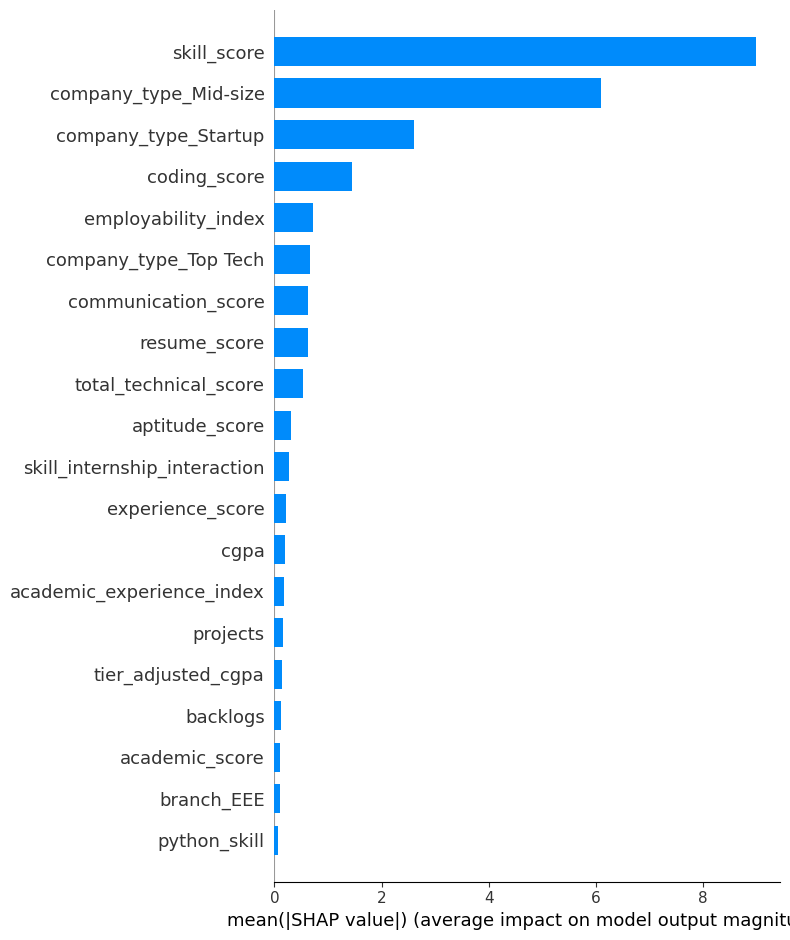

In [10]:
best_reg_row  = results_reg.iloc[0]
best_reg_name = best_reg_row['Model']
best_reg      = {'XGBoost Regressor': res_xgb,
                 'LightGBM Regressor': res_lgb}[best_reg_name]['_fitted']

print(f"Running SHAP on: {best_reg_name}")

# TreeExplainer works natively for XGBoost & LightGBM
explainer   = shap.TreeExplainer(best_reg)
shap_values = explainer.shap_values(X_test)

# 1) Global feature importance (bar)
shap.summary_plot(shap_values, X_test, plot_type='bar', show=True)

This bar chart shows the average impact of each feature on the model's salary predictions (using SHAP values). Higher bars mean the feature has a stronger influence on the predicted salary.

**Insights:**
* `skill_score` is by far the most important feature. This confirms that overall technical ability (Python + DSA + ML + Web Dev) is the strongest driver of higher salary packages.
* Whether a student joins a Startup, Mid-size, or Top Tech company has massive impact on salary. This matches the bimodal salary distribution in the previous notebook.
* `employability_index` ranks well
* `total_technical_score` contributes positively
* `coding_score`, `communication_score`, and `resume_score` all show positive impact so both hard and soft skils matter
* However, academic features are less important since `cgpa`, `academic_score`, and `tier_adjusted_cgpa` have relatively low impact compared to skills and company type

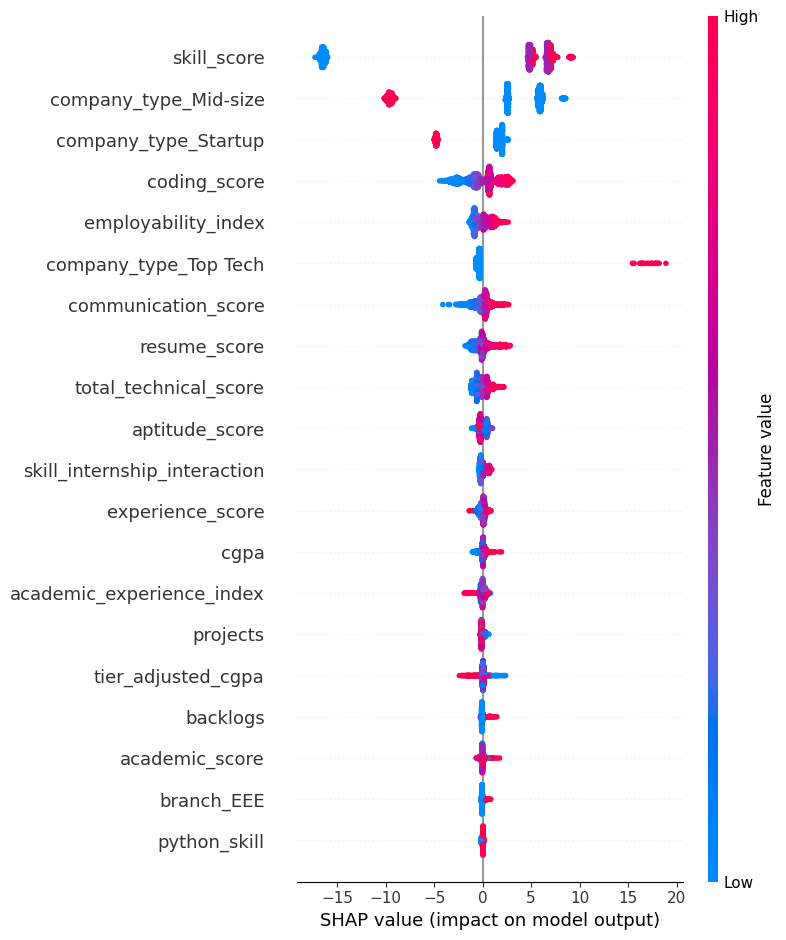

In [11]:
# 2) Beeswarm: direction + magnitude of each feature's effect
shap.summary_plot(shap_values, X_test, show=True)

This plot shows how each feature affects the model's salary predictions for individual students.

**Insights:**
* skill_score is the most powerful feature
* Company Type has massive influence
* `coding_score`, `resume_score`, `communication_score`, and `total_technical_score` all show positive effects when their values are high.
* `backlogs` and `academic_score` show negative or mixed effects.
* For most features, higher values push the prediction upward This is especially clear for `skill_score`, `coding_score`, and `resume_score`.

Top feature: skill_score


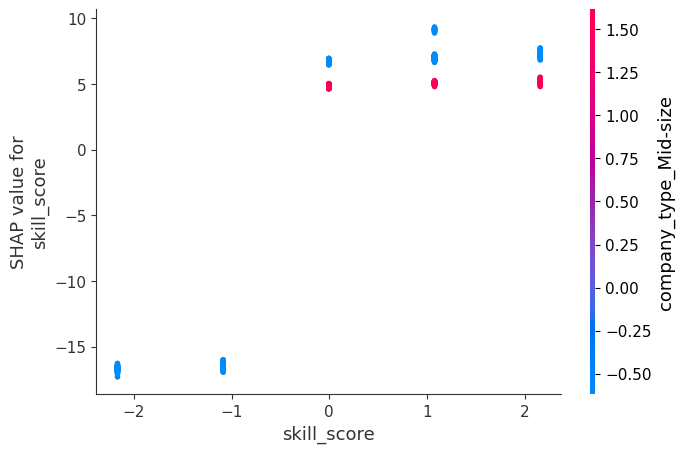

In [12]:
# 3) Dependence plot for the top feature
top_feature = pd.Series(np.abs(shap_values).mean(0),
                        index=X_test.columns).sort_values(ascending=False).index[0]
print("Top feature:", top_feature)
shap.dependence_plot(top_feature, shap_values, X_test, show=True)

This plot shows how the feature `skill_score` affects the predicted salary, and how this effect interacts with another feature (`company_type_Mid-size`).

**Insights:**
* `skill_score` has a consistent positive impact on salary. The higher the skill level, the higher the expected package. The effect becomes particularly strong when `skill_score` is 2 or above.
* Having strong technical skills is good, but combining it with a good company (Mid-size in this case) amplifies the salary boost.
* Even at the same skill level, salary predictions differ based on other factors (like company type, resume, etc.).